In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import torch
from torch.optim import AdamW
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from transformers import AutoTokenizer, AutoModel, get_scheduler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import nltk
nltk.download('punkt')

# ---------------------------
# 1. Cargar datos
# ---------------------------
df = pd.read_json("/content/drive/MyDrive/Titulacion/DatasetsFinales/df_train2_featselect2.jsonl", lines=True)
#df= df.head(30)
X = df.drop('label', axis=1)
y = df['label']

# ---------------------------
# 2. Preprocesamiento de características
# ---------------------------
# TF-IDF
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X['transcription_processed']).toarray()
X_tfidf_df = pd.DataFrame(X_tfidf)

# Características adicionales
X_features = X.iloc[:, 3:]
X_features = X_features.fillna(X_features.mean())

# Unir TF-IDF + Características
combined_df = pd.concat([X_tfidf_df, X_features], axis=1)

combined_df.columns = combined_df.columns.astype(str)
scaler = MinMaxScaler()
normalized_df = scaler.fit_transform(combined_df)
normalized_tensor = torch.tensor(normalized_df, dtype=torch.float32)
labels_tensor = torch.tensor(y.values, dtype=torch.long)

# ---------------------------
# 3. Tokenización con BERT
# ---------------------------
model_name = "clapAI/modernBERT-large-multilingual-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
max_length = 48

encodings = tokenizer(X['transcription_processed'].tolist(),
                      padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt")

# Dataset final
dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], normalized_tensor, labels_tensor)

# ---------------------------
# 4. Dividir en entrenamiento y validación
# ---------------------------
train_size = int(0.8 * len(dataset))
train_dataset, val_dataset = random_split(dataset, [train_size, len(dataset) - train_size])
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16)

# ---------------------------
# 5. Definir Modelo
# ---------------------------
class ModernBERTClassifier(nn.Module):
    def __init__(self, modernbertbert_model, num_extra_features):
        super().__init__()
        self.modernbert = modernbertbert_model
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(modernbertbert_model.config.hidden_size + num_extra_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 2)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_ids, attention_mask, extra_features):
        outputs = self.modernbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        x = torch.cat((cls_output, extra_features), dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.softmax(self.fc2(x))
# ---------------------------
# 6. Entrenamiento con Early Stopping (Basado en pérdida de validación)
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modernbert = AutoModel.from_pretrained(model_name)
model = ModernBERTClassifier(modernbert, normalized_tensor.shape[1]).to(device)

optimizer = AdamW(model.parameters(),  lr=5e-5, weight_decay=0.01)

# Número máximo de épocas (suficientemente alto para permitir Early Stopping)
max_epochs = 100

# Parámetros de Early Stopping
patience = 3  # Número de épocas sin mejora (disminución de la pérdida de validación) antes de detener

scheduler = get_scheduler("cosine", optimizer=optimizer, num_warmup_steps=0, num_training_steps=len(train_dataloader) * max_epochs)

# Calcular pesos de clases
train_labels = [label.item() for _, _, _, label in train_dataset]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
loss_fn = nn.NLLLoss(weight=weights_tensor)

def train_epoch():
    model.train()
    total_loss = 0
    for batch in tqdm(train_dataloader):
        input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, features)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_dataloader)

def evaluate():
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in val_dataloader:
            input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
            outputs = model(input_ids, attention_mask, features)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, axis=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss = total_loss / len(val_dataloader)

    # Calculate metrics (Mantener estas métricas es útil para monitorear el rendimiento)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)

    # Devolver la pérdida de validación y las métricas
    return val_loss, macro_f1, precision, recall, accuracy

# ---------------------------
# 7. Ejecutar entrenamiento con Early Stopping (Basado en pérdida de validación)
# ---------------------------
best_val_loss = float('inf') # Inicializar con infinito positivo para buscar el mínimo
epochs_without_improvement = 0
metrics_history = [] # Para almacenar las métricas de cada época
save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/modernBERT/"
model_save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/roberta/caracteristicas/"
for epoch in range(max_epochs):
    print(f"\nEpoch {epoch + 1}/{max_epochs}")
    train_loss = train_epoch()
    print(f"Train Loss: {train_loss:.4f}")

    # Obtener la pérdida de validación y las métricas
    val_loss, macro_f1, precision, recall, accuracy = evaluate()
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    #print(f"Precision: {precision:.4f}")
    #print(f"Recall: {recall:.4f}")
    #print(f"Accuracy: {accuracy:.4f}")


    # Almacenar las métricas para esta época
    metrics_history.append({
        'Epoch': epoch + 1,
        'Train Loss': train_loss,
        'Validation Loss': val_loss,
        'Macro F1': macro_f1,
        'Precision': precision,
        'Recall': recall,
        'Accuracy': accuracy
    })

    # Lógica de Early Stopping basada en la pérdida de validación
    if val_loss < best_val_loss: # Si la pérdida de validación mejora (disminuye)
        best_val_loss = val_loss
        epochs_without_improvement = 0
        # Opcional: Guardar el mejor modelo (basado en la menor pérdida de validación)
        torch.save(model.state_dict(), save_path + 'best_model_modernBert_loss.pt') # Nombre de archivo diferente para distinguirlo
        joblib.dump(vectorizer, model_save_path + 'tfidf_vectorizer.pkl')
        print(f"Vectorizer guardado en: {model_save_path + 'tfidf_vectorizer.pkl'}")

        joblib.dump(scaler, model_save_path + 'minmax_scaler.pkl')
        print(f"Scaler guardado en: {model_save_path + 'minmax_scaler.pkl'}")

        tokenizer.save_pretrained(model_save_path + 'tokenizer_files/')
        print(f"Tokenizer guardado en: {model_save_path + 'tokenizer_files/'}")
        feature_columns = X_features.columns.tolist()
        joblib.dump(feature_columns, model_save_path + 'feature_columns.pkl')
    else: # Si la pérdida de validación no mejora
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping después de {patience} épocas sin mejora en la pérdida de validación.")
            break # Detiene el entrenamiento

# Mostrar la tabla de métricas al final
print("\nMétricas por Época:")
metrics_df = pd.DataFrame(metrics_history)
display(metrics_df)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Epoch 1/100


100%|██████████| 300/300 [03:12<00:00,  1.56it/s]


Train Loss: 0.5991


W0526 16:47:42.952000 2321 torch/_inductor/utils.py:1137] [1/1] Not enough SMs to use max_autotune_gemm mode


...

100%|██████████| 300/300 [03:06<00:00,  1.61it/s]


Train Loss: 0.1065
Validation Loss: 0.3558
Macro F1: 0.8582

Epoch 7/100


100%|██████████| 300/300 [03:06<00:00,  1.60it/s]


Train Loss: 0.0617
Validation Loss: 0.4693
Macro F1: 0.8495
Early stopping después de 3 épocas sin mejora en la pérdida de validación.

Métricas por Época:


,Epoch,Train Loss,Validation Loss,Macro F1,Precision,Recall,Accuracy
0,1,0.599081,0.653628,0.799687,0.835441,0.799886,0.806667
1,2,0.597998,0.475372,0.769063,0.814617,0.771316,0.779167
2,3,0.447035,0.340410,0.847808,0.859274,0.846314,0.850000
3,4,0.313096,0.311643,0.874838,0.879581,0.873590,0.875833
4,5,0.197649,0.360478,0.860228,0.861599,0.859612,0.860833
5,6,0.106500,0.355839,0.858220,0.858120,0.858797,0.858333
6,7,0.061662,0.469296,0.849458,0.850283,0.849019,0.850000


In [ ]:
best_epoch_metrics = metrics_df.loc[metrics_df['Macro F1'].idxmax()]
print("\nResultados de la mejor época:")
display(best_epoch_metrics)


Resultados de la mejor época:


,3
Epoch,4.000000
Train Loss,0.313096
Validation Loss,0.311643
Macro F1,0.874838
Precision,0.879581
Recall,0.873590
Accuracy,0.875833


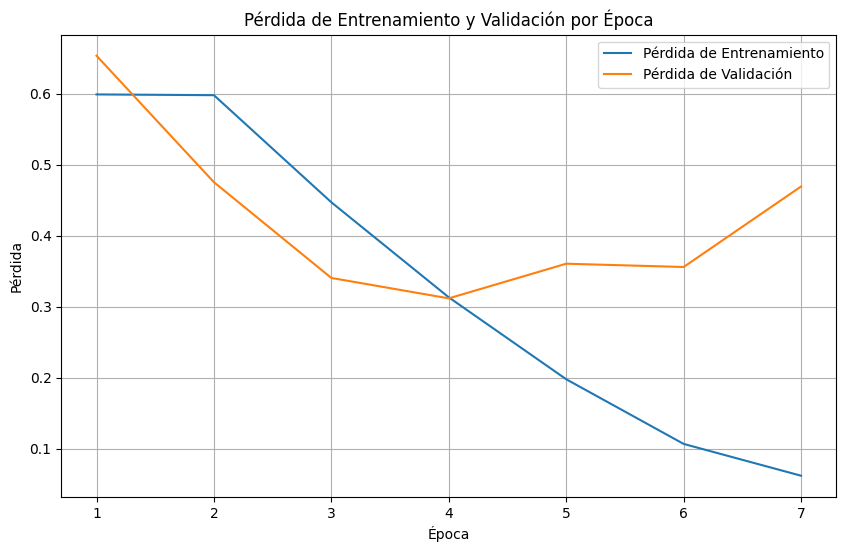

In [ ]:
# ---------------------------
# 8. Visualizar pérdidas
# ---------------------------
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Epoch'], metrics_df['Train Loss'], label='Pérdida de Entrenamiento')
plt.plot(metrics_df['Epoch'], metrics_df['Validation Loss'], label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación por Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

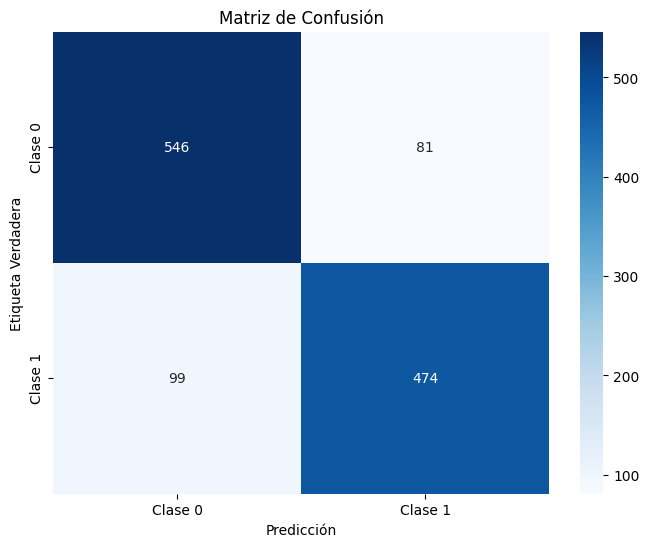

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 9. Obtener predicciones del mejor modelo en el conjunto de validación
# ---------------------------
model.eval() # Poner el modelo en modo evaluación
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_dataloader:
        input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
        outputs = model(input_ids, attention_mask, features)
        preds = torch.argmax(outputs, axis=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---------------------------
# 10. Generar y graficar la matriz de confusión
# ---------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()